In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [36]:
movies = pd.read_csv('../data/Movies_clean.csv')

In [37]:
movies.head()

,Title,MPAA Rating,Budget,Gross,Release Date,Genre,Runtime,Rating,Rating Count,Summary,Gross Profit
0,Look Who's Talking,PG-13,7500000,296000000,1989-10-12,Romance,93,5.9,73638.0,"After a single, career-minded woman is left on...",288500000
1,Driving Miss Daisy,PG,7500000,145793296,1989-12-13,Comedy,99,7.4,91075.0,An old Jewish woman and her African-American c...,138293296
2,Turner & Hooch,PG,13000000,71079915,1989-07-28,Crime,100,7.2,91415.0,"Det. Scott Turner (Tom Hanks) is an uptight, b...",58079915
3,Born on the Fourth of July,R,14000000,161001698,1989-12-20,War,145,7.2,91415.0,The biography of Ron Kovic. Paralyzed in the V...,147001698
4,Field of Dreams,PG,15000000,84431625,1989-04-21,Drama,107,7.5,101702.0,"An Iowa corn farmer, hearing voices, interpret...",69431625


In [38]:
# change Gross Profit to Net Profit
movies.rename(columns={'Gross Profit': 'Net Profit'}, inplace=True)
# creat ROI column
movies['ROI'] = movies['Net Profit'] / movies['Budget']

In [39]:
# inspecting the movie database
movies.shape

(507, 12)

In [40]:
# inspect numeric data
movies.describe()

,Budget,Gross,Runtime,Rating,Rating Count,Net Profit,ROI
count,5.070000e+02,5.070000e+02,507.000000,507.000000,5.070000e+02,5.070000e+02,507.000000
mean,8.390437e+07,3.822130e+08,117.761341,6.916371,3.379779e+05,2.983086e+08,13.247565
std,5.981288e+07,2.777467e+08,22.703891,0.884533,3.172865e+05,2.428229e+08,183.385360
min,6.000000e+04,5.300000e+07,79.000000,4.100000,1.491800e+04,1.820300e+04,0.000152
25%,3.505000e+07,1.961144e+08,100.000000,6.400000,1.273915e+05,1.462232e+08,2.108191
50%,7.000000e+07,3.094575e+08,115.000000,6.900000,2.401600e+05,2.301564e+08,3.418503
75%,1.250000e+08,4.800242e+08,130.000000,7.600000,4.269280e+05,3.860487e+08,5.921667
max,3.800000e+08,2.787965e+09,201.000000,9.000000,2.127228e+06,2.550965e+09,4132.333333


In [41]:
movies.dtypes

Title            object
MPAA Rating      object
Budget            int64
Gross             int64
Release Date     object
Genre            object
Runtime           int64
Rating          float64
Rating Count    float64
Summary          object
Net Profit        int64
ROI             float64
dtype: object

In [42]:
# the dates need fixed
movies['Release Date'] = pd.to_datetime(movies['Release Date'])
movies.head()

,Title,MPAA Rating,Budget,Gross,Release Date,Genre,Runtime,Rating,Rating Count,Summary,Net Profit,ROI
0,Look Who's Talking,PG-13,7500000,296000000,1989-10-12,Romance,93,5.9,73638.0,"After a single, career-minded woman is left on...",288500000,38.466667
1,Driving Miss Daisy,PG,7500000,145793296,1989-12-13,Comedy,99,7.4,91075.0,An old Jewish woman and her African-American c...,138293296,18.439106
2,Turner & Hooch,PG,13000000,71079915,1989-07-28,Crime,100,7.2,91415.0,"Det. Scott Turner (Tom Hanks) is an uptight, b...",58079915,4.467686
3,Born on the Fourth of July,R,14000000,161001698,1989-12-20,War,145,7.2,91415.0,The biography of Ron Kovic. Paralyzed in the V...,147001698,10.500121
4,Field of Dreams,PG,15000000,84431625,1989-04-21,Drama,107,7.5,101702.0,"An Iowa corn farmer, hearing voices, interpret...",69431625,4.628775


In [43]:
# change Net Profit to float to prevent errors in calculations
movies['Net Profit'] = movies['Net Profit'].astype(float)
# change gross to float to prevent errors in calculations
movies['Gross'] = movies['Gross'].astype(float)
# change runtime to float to prevent errors in calculations
movies['Runtime'] = movies['Runtime'].astype(float)
# change Budget to float to prevent errors in calculations
movies['Budget'] = movies['Budget'].astype(float)
movies.dtypes

Title                   object
MPAA Rating             object
Budget                 float64
Gross                  float64
Release Date    datetime64[ns]
Genre                   object
Runtime                float64
Rating                 float64
Rating Count           float64
Summary                 object
Net Profit             float64
ROI                    float64
dtype: object

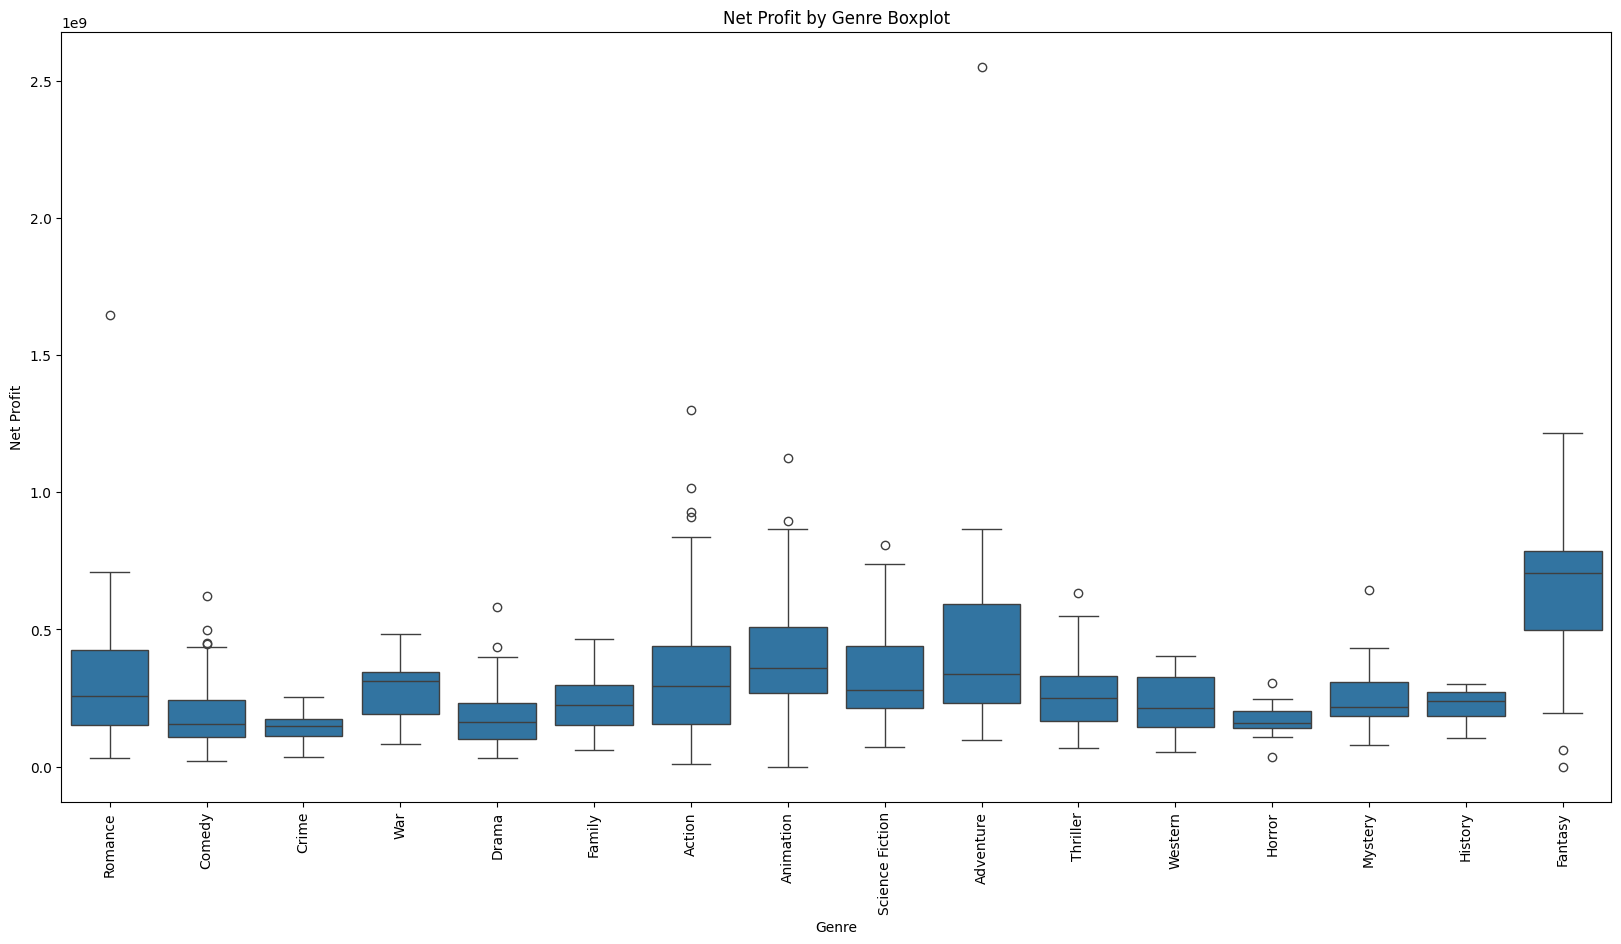

In [44]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=movies, x='Genre', y='Net Profit')
plt.xticks(rotation=90)
plt.title('Net Profit by Genre Boxplot')
plt.suptitle('')
plt.show()

In [45]:
# List the movies with the highest net profit
movies.sort_values('Net Profit', ascending=False)[['Title', 'Net Profit','Genre']].head(10)

,Title,Net Profit,Genre
413,Avatar,2.550965e+09,Adventure
176,Titanic,1.645034e+09,Romance
470,The Avengers,1.299558e+09,Action
444,Harry Potter and the Deathly Hallows: Part 2,1.217000e+09,Fantasy
484,Frozen,1.124219e+09,Animation
286,The Lord of the Rings: The Return of the King,1.024889e+09,Fantasy
487,Iron Man 3,1.015440e+09,Action
451,Transformers: Dark of the Moon,9.287470e+08,Action
468,Skyfall,9.085610e+08,Action
479,Despicable Me 2,8.947619e+08,Animation


In [46]:
# we are going to drop Avatar and Titanic because they are extreme outliers in the Romance and Adventure Genres
movies = movies[~movies['Title'].isin(['Avatar', 'Titanic'])]

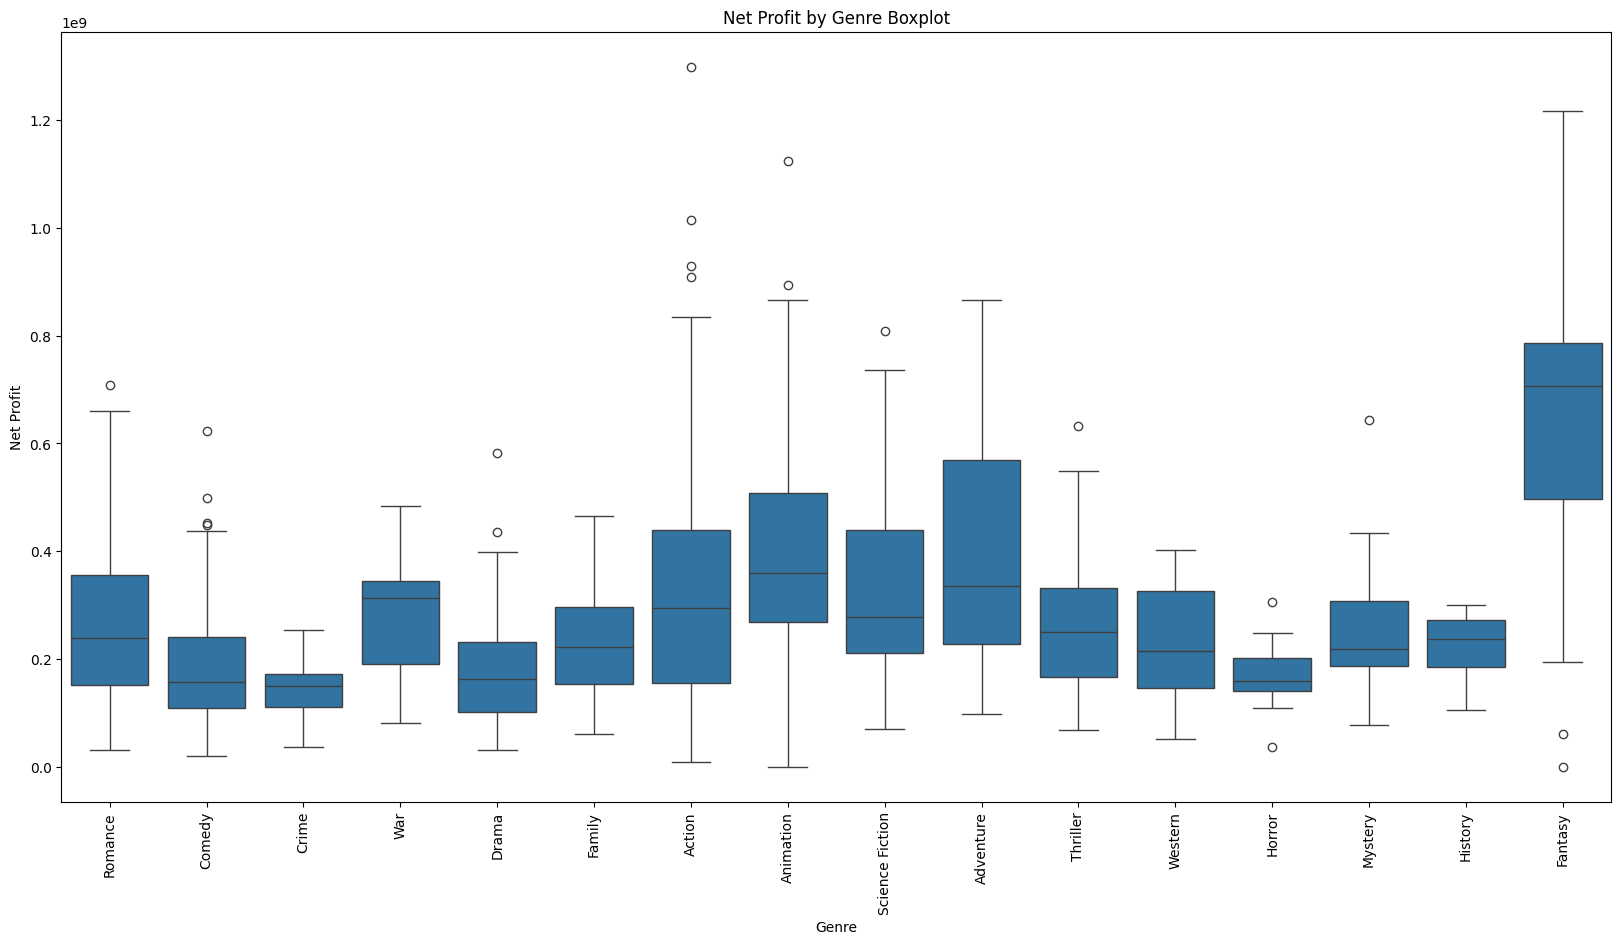

In [47]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=movies, x='Genre', y='Net Profit')
plt.xticks(rotation=90)
plt.title('Net Profit by Genre Boxplot')
plt.suptitle('')
plt.show()

Different movie genres have different ranges of gross profit and potential to be an outlier. Fantasy looks like the highest grossing genere with action or adventure as the highest grossing outliers.

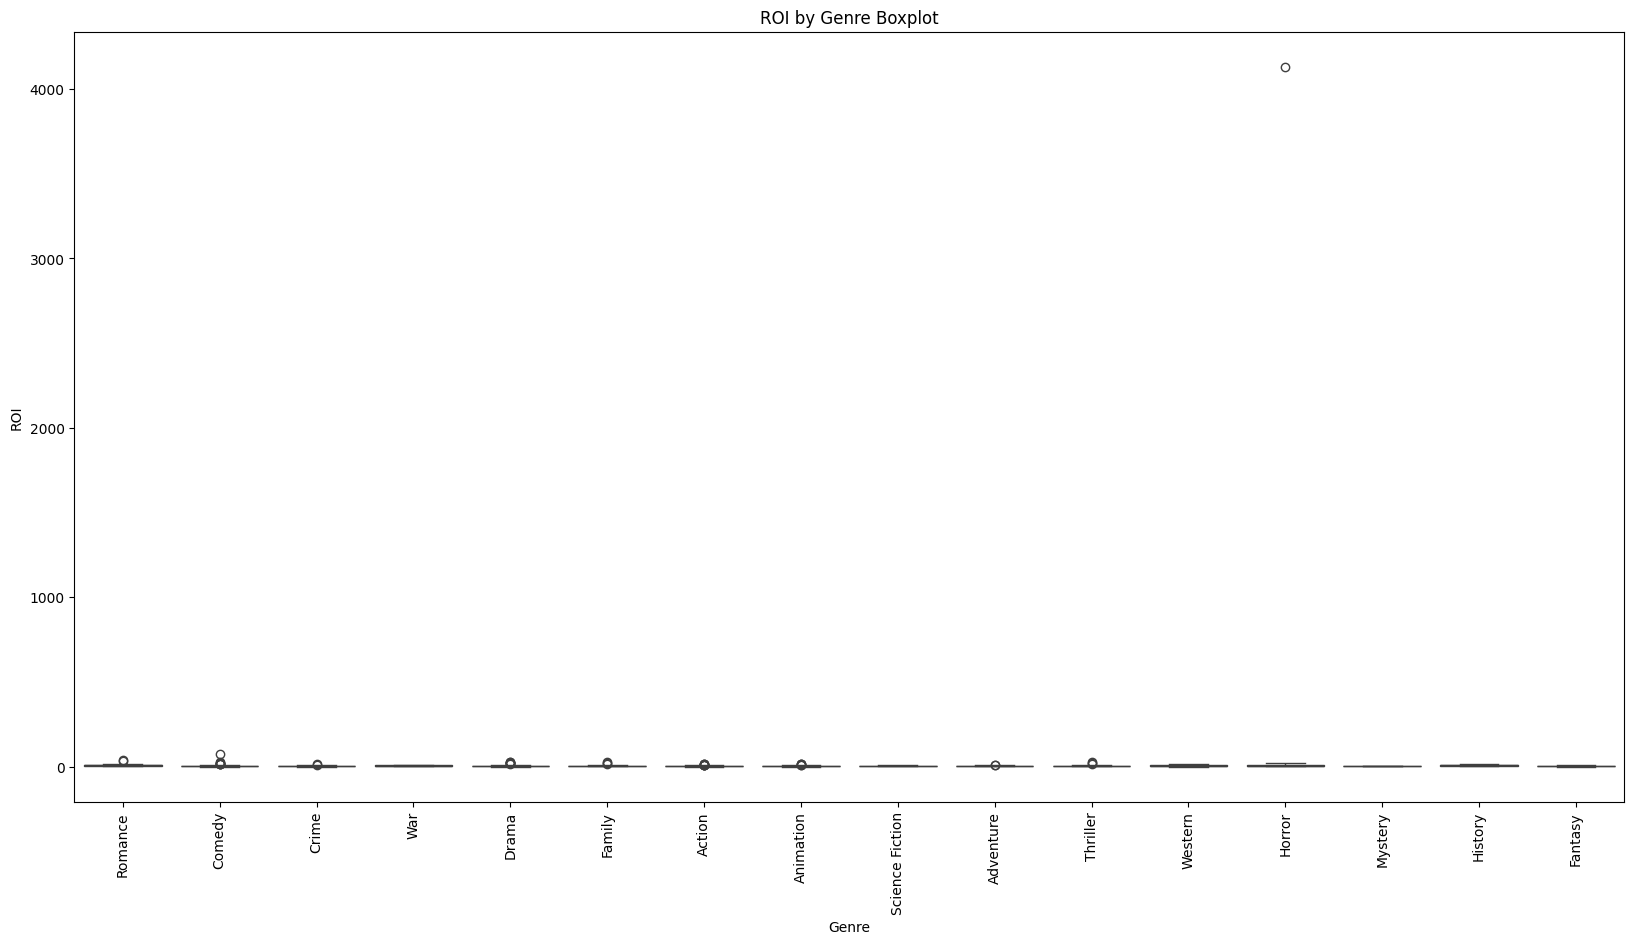

In [48]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=movies, x='Genre', y='ROI')
plt.xticks(rotation=90)
plt.title('ROI by Genre Boxplot')
plt.suptitle('')
plt.show()

In [49]:
#show top ten movies by ROI
movies.nlargest(10, 'ROI')

,Title,MPAA Rating,Budget,Gross,Release Date,Genre,Runtime,Rating,Rating Count,Summary,Net Profit,ROI
197,The Blair Witch Project,R,60000.0,248000000.0,1999-07-14,Horror,81.0,6.5,220304.0,Three film students vanish after traveling int...,247940000.0,4132.333333
256,My Big Fat Greek Wedding,PG,5000000.0,368744044.0,2002-02-22,Comedy,95.0,6.5,114907.0,A young Greek woman falls in love with a non-G...,363744044.0,72.748809
0,Look Who's Talking,PG-13,7500000.0,296000000.0,1989-10-12,Romance,93.0,5.9,73638.0,"After a single, career-minded woman is left on...",288500000.0,38.466667
22,Pretty Woman,R,14000000.0,463000000.0,1990-03-23,Romance,119.0,7.0,266405.0,A man in a legal but hurtful business needs an...,449000000.0,32.071429
355,Juno,PG-13,7500000.0,231411584.0,2007-12-05,Comedy,96.0,7.4,471466.0,"Faced with an unplanned pregnancy, an offbeat ...",223911584.0,29.854878
415,The King's Speech,R,15000000.0,414211549.0,2010-09-06,Drama,118.0,8.0,603556.0,"The story of King George VI, his impromptu asc...",399211549.0,26.614103
98,Pulp Fiction,R,8000000.0,213928762.0,1994-09-10,Thriller,154.0,8.9,1690474.0,"The lives of two mob hitmen, a boxer, a gangst...",205928762.0,25.741095
24,Home Alone,PG,18000000.0,476684675.0,1990-11-09,Family,103.0,7.6,414472.0,An eight-year-old troublemaker must protect hi...,458684675.0,25.482482
375,Slumdog Millionaire,R,15000000.0,377910544.0,2008-05-12,Drama,120.0,8.0,758215.0,A Mumbai teenager reflects on his life after b...,362910544.0,24.194036
474,The Conjuring,R,13000000.0,318000141.0,2013-07-18,Horror,112.0,7.5,410378.0,Paranormal investigators Ed and Lorraine Warre...,305000141.0,23.461549


In [50]:
# becasue the blair witch project ROP is an outlier we are going to drop it
movies = movies[movies['Title'] != 'The Blair Witch Project']

#show top ten movies by ROI
movies.nlargest(4, 'ROI')

,Title,MPAA Rating,Budget,Gross,Release Date,Genre,Runtime,Rating,Rating Count,Summary,Net Profit,ROI
256,My Big Fat Greek Wedding,PG,5000000.0,368744044.0,2002-02-22,Comedy,95.0,6.5,114907.0,A young Greek woman falls in love with a non-G...,363744044.0,72.748809
0,Look Who's Talking,PG-13,7500000.0,296000000.0,1989-10-12,Romance,93.0,5.9,73638.0,"After a single, career-minded woman is left on...",288500000.0,38.466667
22,Pretty Woman,R,14000000.0,463000000.0,1990-03-23,Romance,119.0,7.0,266405.0,A man in a legal but hurtful business needs an...,449000000.0,32.071429
355,Juno,PG-13,7500000.0,231411584.0,2007-12-05,Comedy,96.0,7.4,471466.0,"Faced with an unplanned pregnancy, an offbeat ...",223911584.0,29.854878


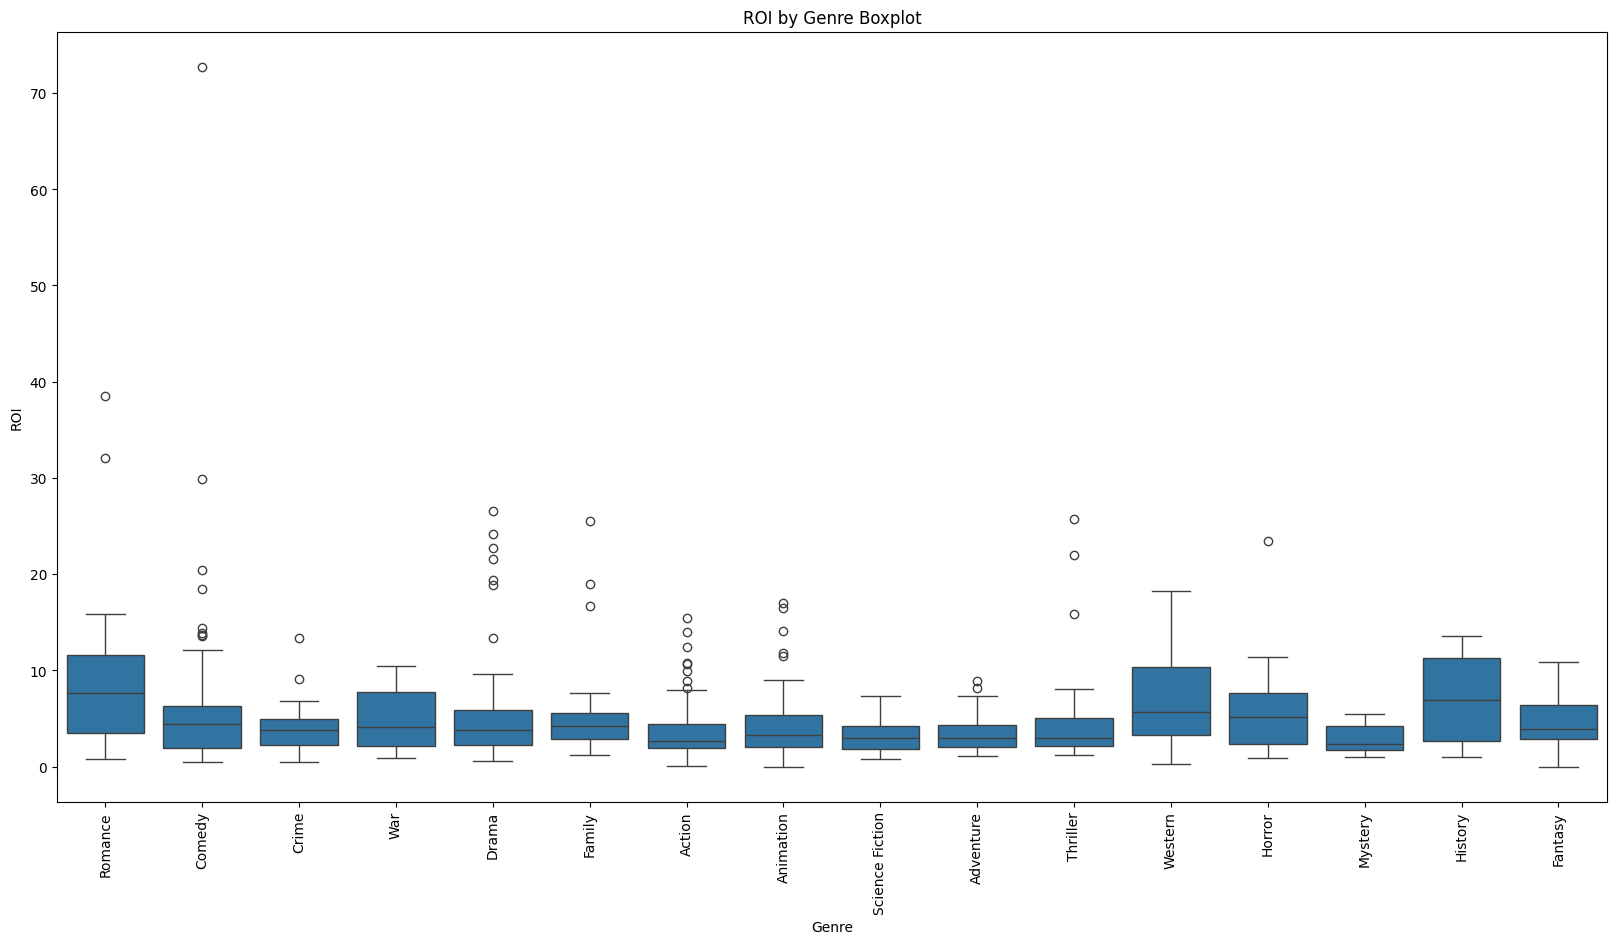

In [51]:
plt.figure(figsize=(20, 10))
sns.boxplot(
    data=movies, 
    x='Genre',
    y='ROI'
)
plt.xticks(rotation=90)
plt.title('ROI by Genre Boxplot')
plt.suptitle('')
plt.show()

Looking at the ROI by genere, The blair witch project is a major outlier at over 4000, if we remove it we can see the rest of the data more clearly. My Big Fat Greek Wedding is the second highest ROI at 75. 

Most the generes are below the overall mean of about 13% ROI, the outliers significantly raise it.

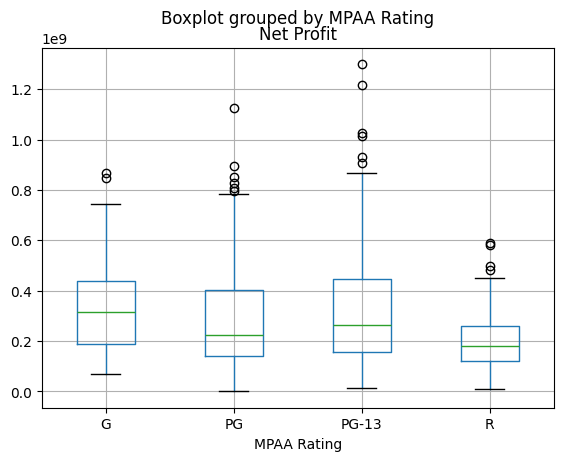

In [52]:
movies.boxplot(column='Net Profit', by='MPAA Rating')

plt.show()

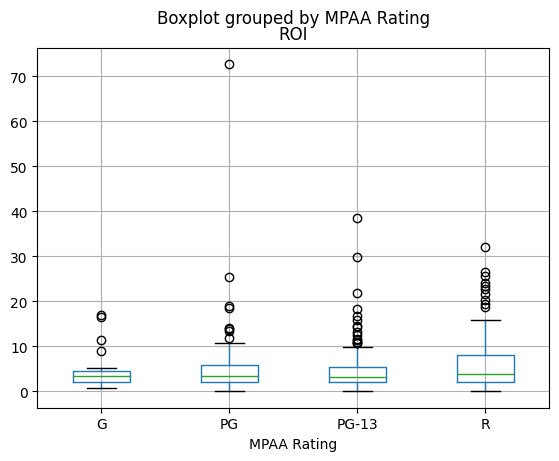

In [53]:
movies.boxplot(column='ROI', by='MPAA Rating')

plt.show()

These box plot of MPAA Ratings show that while movies have similar ranges Net Profit and ROI, there is a higher chance of getting a big box office hit if the movie is PG - 13, indicated by the outliers. 

R movies seem to have a much smaller variation in Profit compared to the other ratings as well.
But R movies have a better ROI, with The blair which project being the highest.

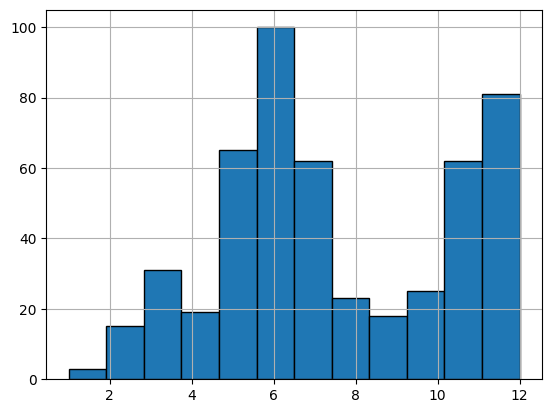

In [54]:
# Moives are more likley to be relasese in the summer or winter.

movies['Release Date'].dt.month.hist(bins=12, edgecolor='black')

plt.show()

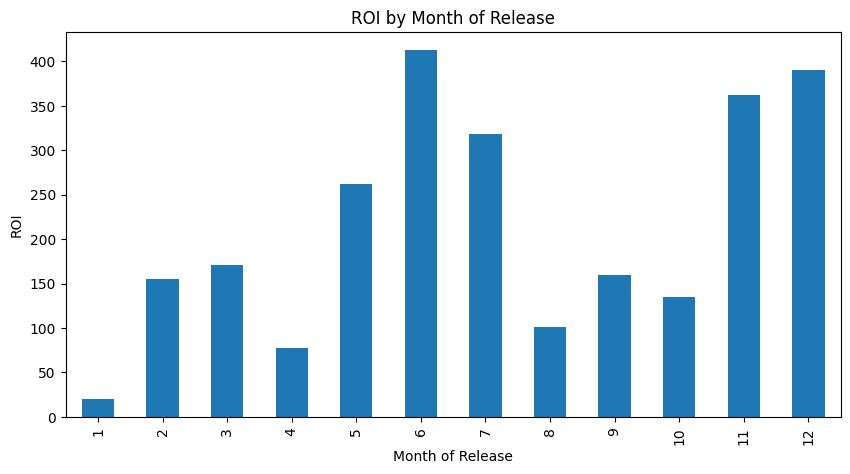

In [55]:
# make a chart of release dates by month vs net profit without index 197 the blair witch, so we can see the other movies more clearly
movies.groupby(movies['Release Date'].dt.month)['ROI'].sum().plot(kind='bar', figsize=(10, 5))
plt.title('ROI by Month of Release')
plt.xlabel('Month of Release')
plt.ylabel('ROI')
plt.xticks(rotation=90)
plt.show()

The ROI bar chart matches the release date histogram
The blair witch ROI has been changed becasue its an outlier, but came out in July with an ROI of 4000.


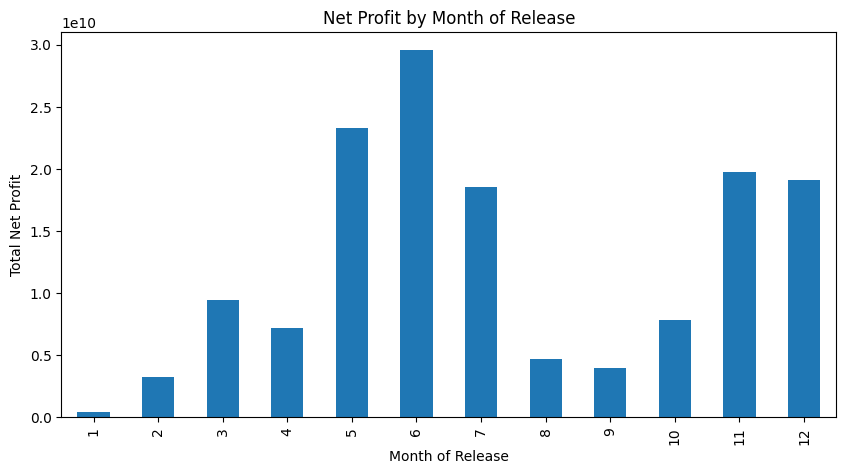

In [56]:
# make a chart of release dates by month vs net profit
movies.groupby(movies['Release Date'].dt.month)['Net Profit'].sum().plot(kind='bar', figsize=(10, 5))
plt.title('Net Profit by Month of Release')
plt.xlabel('Month of Release')
plt.ylabel('Total Net Profit')
plt.xticks(rotation=90)
plt.show()

The net profits also corrilate very well with the release dates of the movies.

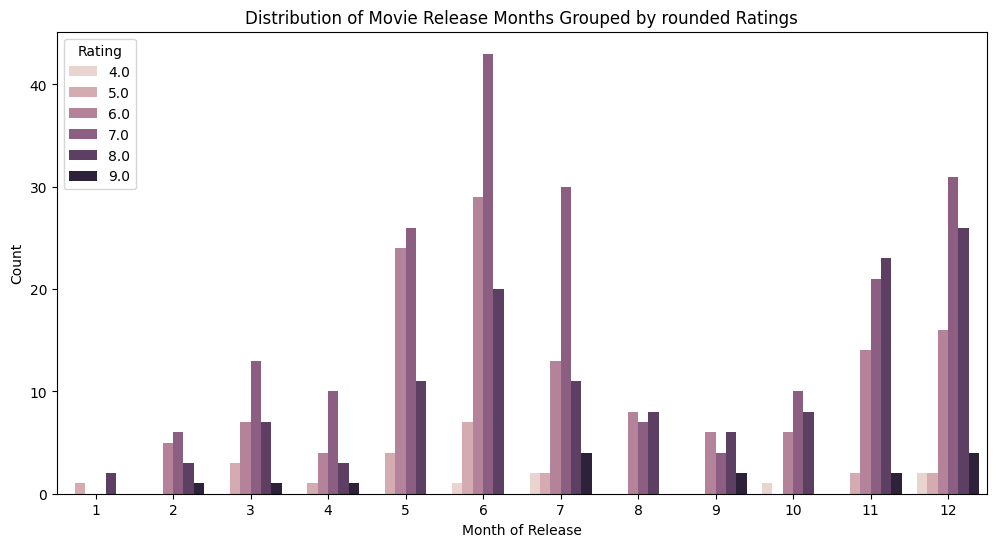

In [57]:
plt.figure(figsize=(12, 6))
# Create a new column for whole number ratings
Rating_Whole = movies['Rating'].round(0)
sns.countplot(
    data=movies,
    x=movies['Release Date'].dt.month,
    hue=Rating_Whole
)
plt.title('Distribution of Movie Release Months Grouped by rounded Ratings')
plt.xlabel('Month of Release')
plt.ylabel('Count')
plt.xticks(range(0, 12), [str(i) for i in range(1, 13)])
plt.show()

This chart shows the distribution of movie release months grouped by number review ratings. You can see best rated movies come out in the summer and winter. Also the months have normal distributions for the most part.

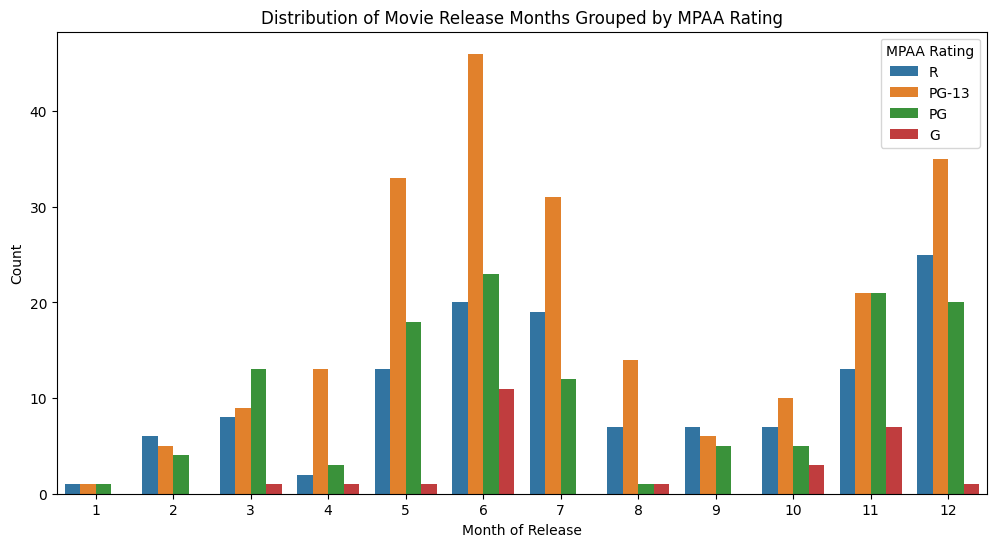

In [58]:
plt.figure(figsize=(12, 6))
sns.countplot(
    data=movies,
    x=movies['Release Date'].dt.month,
    hue='MPAA Rating'
)
plt.title('Distribution of Movie Release Months Grouped by MPAA Rating')
plt.xlabel('Month of Release')
plt.ylabel('Count')
plt.xticks(range(0, 12), [str(i) for i in range(1, 13)])
plt.show()

The MPAA ratings have somewhat normal distrubutions across the month if PG-13 is the mean. Most moviews are rated PG-13.

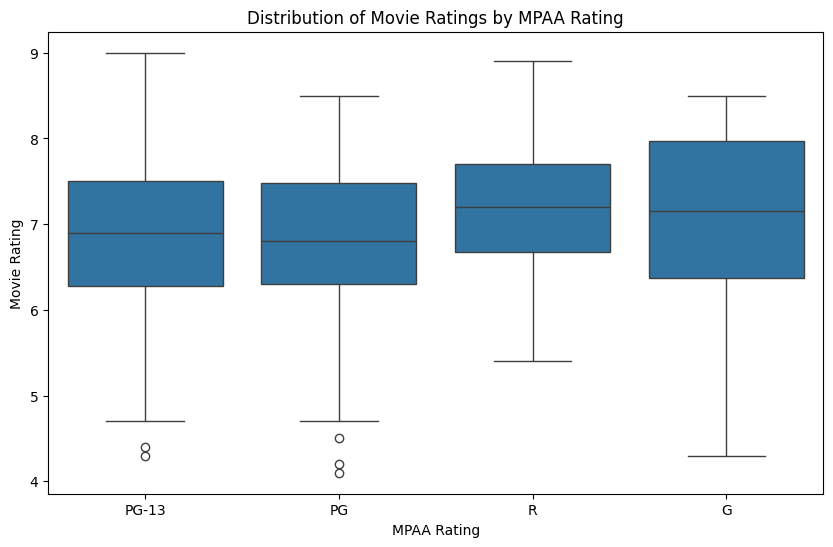

In [59]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=movies,
    x='MPAA Rating',
    y='Rating'
)
plt.title('Distribution of Movie Ratings by MPAA Rating')
plt.xlabel('MPAA Rating')
plt.ylabel('Movie Rating')
plt.show()

The review ratings have normal distributions compared to the MPAA Ratings. PG-13 and R have the highest range, and R over all has the best reviews on average.

In [60]:
#making a corrilation table
numeric = ['Release Date','Rating','Budget','Gross','Runtime','Rating Count','Net Profit','ROI']
movies[numeric].corr()

,Release Date,Rating,Budget,Gross,Runtime,Rating Count,Net Profit,ROI
Release Date,1.000000,-0.018066,0.581022,0.545786,0.049895,0.292234,0.474080,-0.130031
Rating,-0.018066,1.000000,0.012263,0.229864,0.369038,0.662830,0.264190,0.179752
Budget,0.581022,0.012263,1.000000,0.668835,0.243004,0.287585,0.501018,-0.396112
Gross,0.545786,0.229864,0.668835,1.000000,0.272471,0.504918,0.978474,0.088852
Runtime,0.049895,0.369038,0.243004,0.272471,1.000000,0.393776,0.249737,-0.038652
Rating Count,0.292234,0.662830,0.287585,0.504918,0.393776,1.000000,0.507963,0.127620
Net Profit,0.474080,0.264190,0.501018,0.978474,0.249737,0.507963,1.000000,0.213397
ROI,-0.130031,0.179752,-0.396112,0.088852,-0.038652,0.127620,0.213397,1.000000


<Axes: >

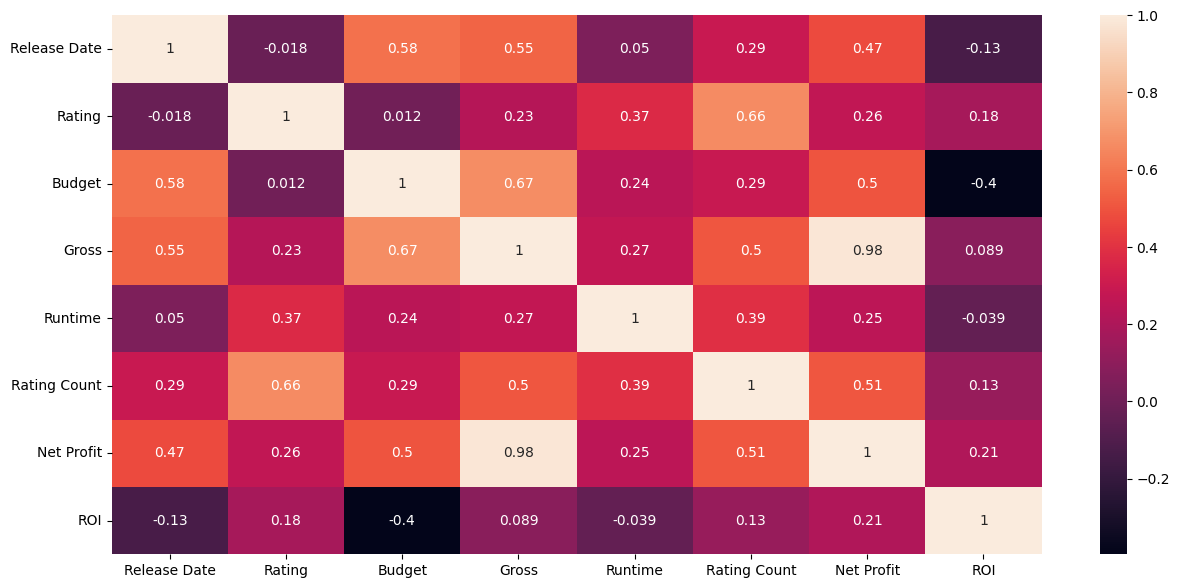

In [61]:
# making a heatmap for corrilations
plt.figure(figsize=(15,7))
sns.heatmap(movies[numeric].corr(), annot=True)

The gross and gross profit correlate because they are built on each other.

Movies with higher ratings also have a higher rating count or reviews, indicating they are more popular.

the gross also correlates with budget and rating count.

Release date also has a strong corrilation to budget and gross.

The ROI shows corrialtion when the Blair Witch project is not included as an outlier.

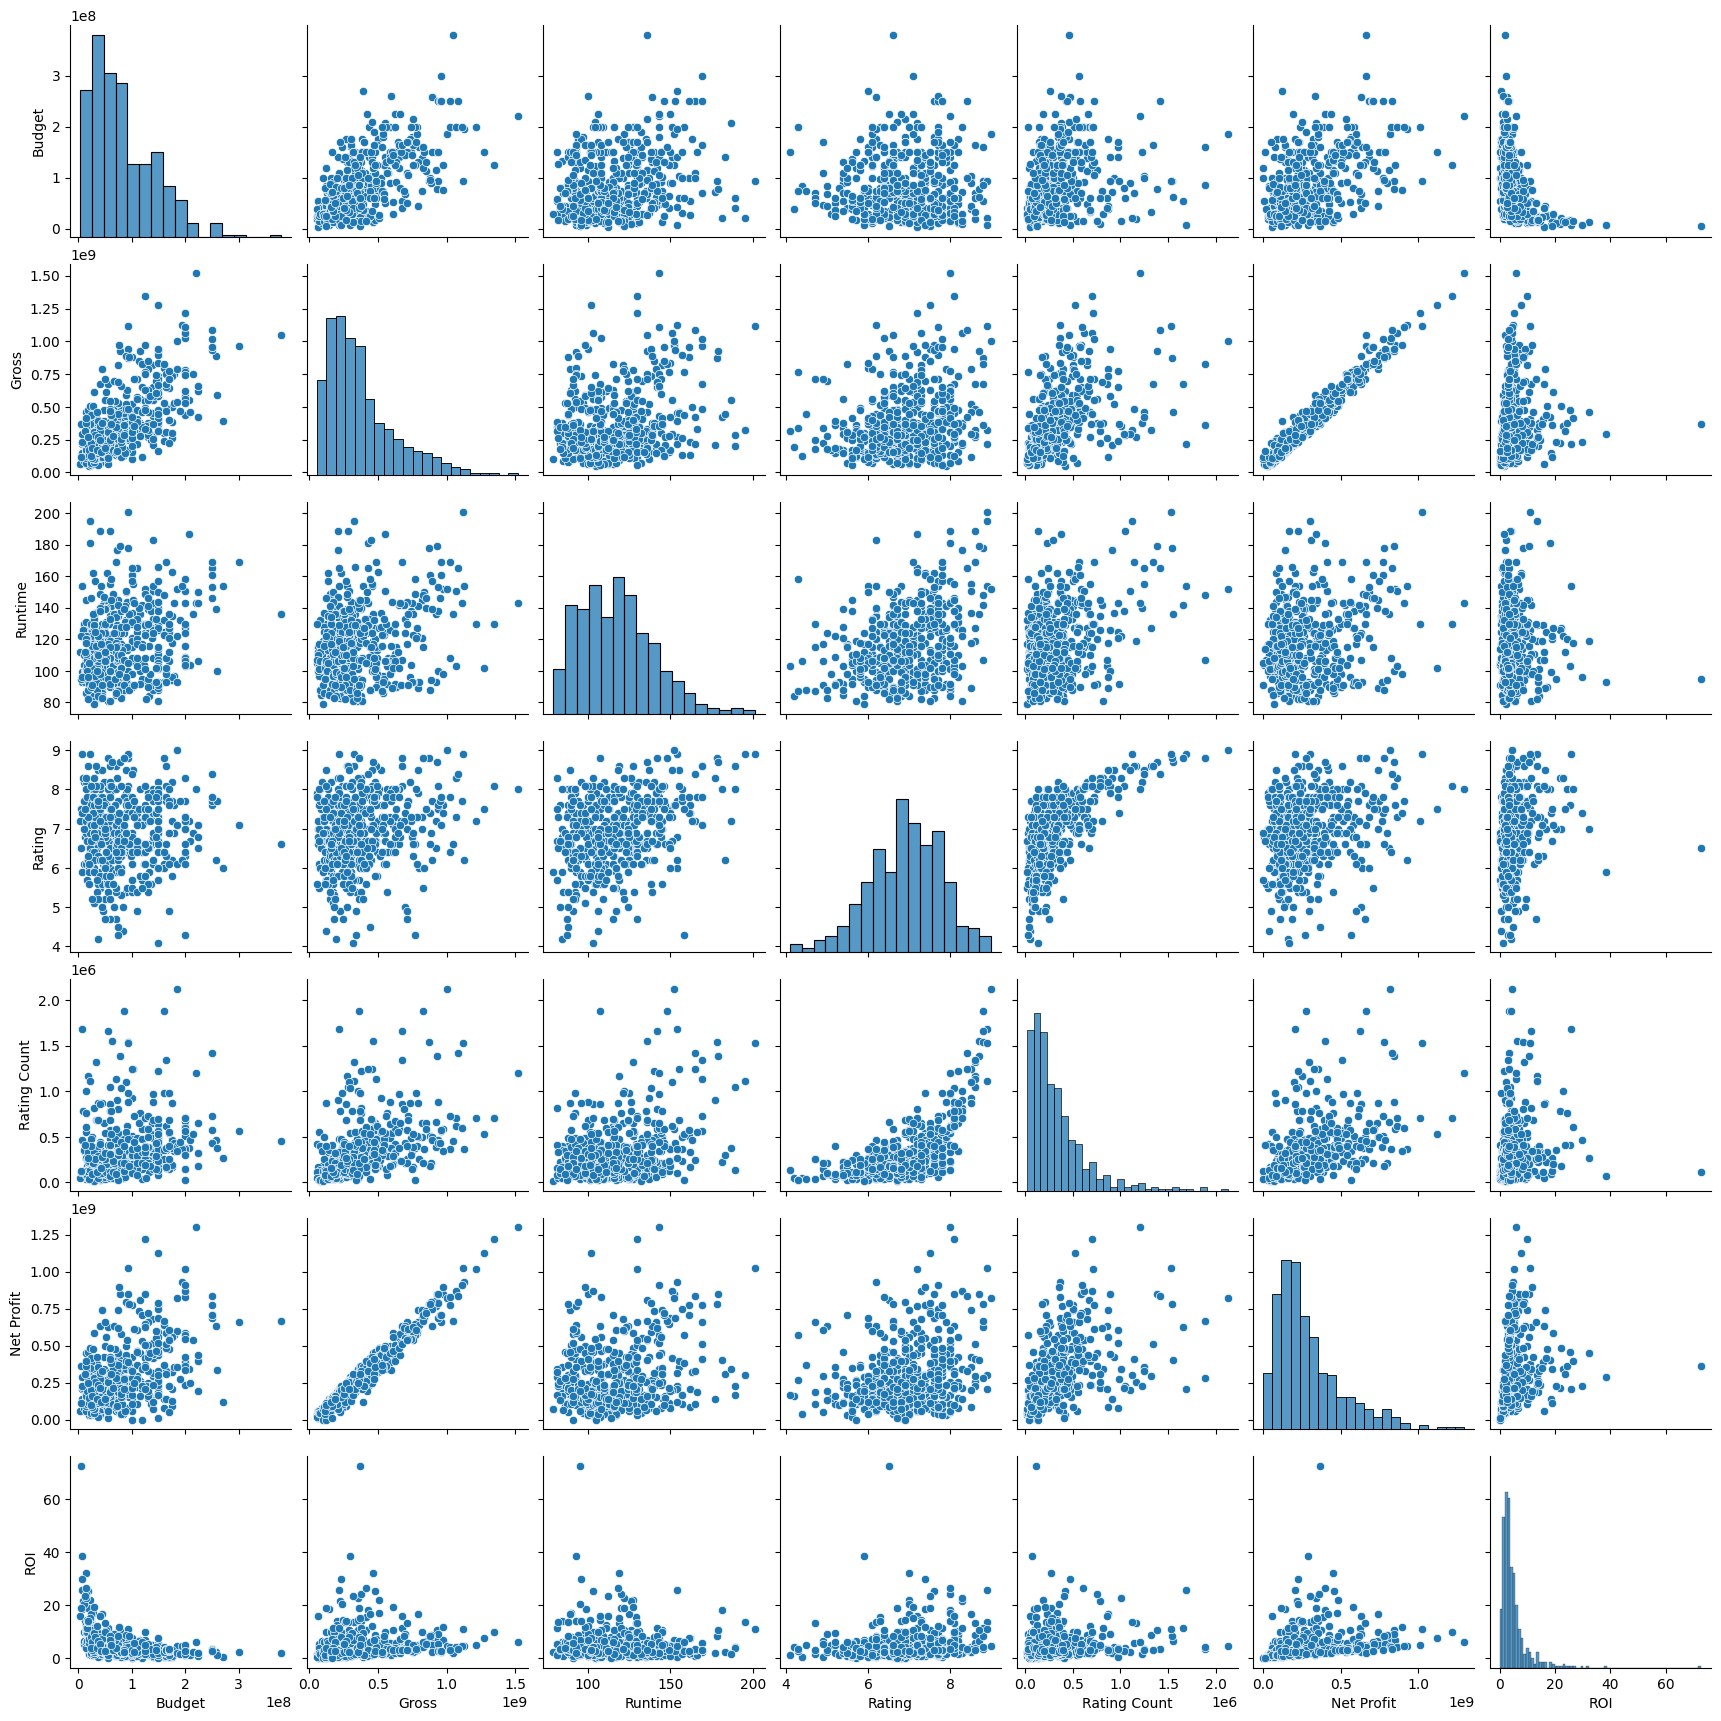

In [62]:
# making a pairplot
sns.pairplot(movies)
plt.show()

The pairplot shows similar things to the heatmap, but it is easier to visulaize. 

In conclusion, there are many factors that correlate with over all gross profit of moives. 

the ratings, rating count, budget, Release Date, genre, and MPAA rating all can be used to help predict net proftis.

Based on the current findings, a high budget PG-13 fantasy/action/adventure movie released around June or December would have the most potential for a high net profit.

In [63]:
# Save the current movies DataFrame to a CSV file
movies.to_csv('../data/Movies_EDA.csv', index=False)